# Trabajo 1: Análisis Geodemográfico CENSO 2017 - Gran Santiago
Alumno:

## 1. Introducción
nnnnnnn

## 2. Objetivos
- Generar...

## Desarrollo

In [24]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text
from sqlalchemy import create_engine

## Conexión a Base de Datos


In [7]:
DB_HOST     = 'localhost'
DB_PORT     = 5432
DB_NAME     = 'censo_rm_2017'
DB_USER     = 'postgres'
DB_PASSWORD = 'postgres'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)
print('Conexion exitosa al servidor PostgreSQL')

Conexion exitosa al servidor PostgreSQL


In [9]:
#Consulta simple

consulta_simple = '''
SELECT * FROM hogares
'''

In [10]:
hogares = pd.read_sql(consulta_simple, con = engine)

In [12]:
hogares

,hogar_ref_id,vivienda_ref_id,nhogar,tipo_hogar,ncu_yern_nuer,n_herm_cun,nuc_herm_cun,num_sueg_pad_abu,nuc_pad_sueg_abu,num_otros,nuc_otros,num_no_par,nuc_no_par,tot_nucleos
0,3809281,4507324,0,2,0,0,0,0,0,0,0,0,0,0
1,3809282,4507325,0,4,0,0,0,0,0,0,0,0,0,0
2,3809283,4507326,0,1,0,0,0,0,0,0,0,0,0,0
3,3809284,4507327,0,1,0,0,0,0,0,0,0,0,0,0
4,3809285,4507328,0,4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2240546,5467995,6269301,0,2,0,0,0,0,0,0,0,0,0,0
2240547,5468016,6269325,0,3,0,0,0,0,0,0,0,0,0,0
2240548,5468047,6269358,0,6,0,0,0,0,0,0,0,0,0,0
2240549,5466945,6268167,0,6,0,0,0,0,0,2,1,0,0,1


In [16]:
sql_comunas = '''
WITH agg AS (
    SELECT
        c.nom_comuna,
        ROUND(
            COUNT(*) FILTER (WHERE p.p12 NOT IN (1, 2, 98, 99)) * 100.0 / COUNT(*), 2
        ) AS ptje_migrantes,
        ROUND(
            COUNT(*) FILTER (WHERE p.escolaridad >= 16) * 100.0 / COUNT(*), 2
        ) AS ptje_esc_mayor_16
    FROM public.personas   AS p
    JOIN public.hogares    AS h  ON p.hogar_ref_id    = h.hogar_ref_id
    JOIN public.viviendas  AS v  ON h.vivienda_ref_id = v.vivienda_ref_id
    JOIN public.zonas      AS z  ON v.zonaloc_ref_id  = z.zonaloc_ref_id
    JOIN public.comunas    AS c  ON z.codigo_comuna   = c.codigo_comuna
    JOIN public.provincias AS pr ON pr.provincia_ref_id = c.provincia_ref_id
    WHERE pr.nom_provincia = 'SANTIAGO'
       OR c.nom_comuna IN ('PUENTE ALTO', 'SAN BERNARDO')
    GROUP BY c.nom_comuna
)
SELECT a.nom_comuna, shp.geom, a.ptje_migrantes, a.ptje_esc_mayor_16
FROM agg AS a
JOIN dpa.comunas_rm_shp AS shp ON UPPER(shp.nom_comuna) = a.nom_comuna;

'''

In [17]:
# Se lee la consulta para obtener indicadores a nivel de comuna
gdf_comuna = gpd.read_postgis(sql_comunas,  engine, geom_col = 'geom')

<Axes: >

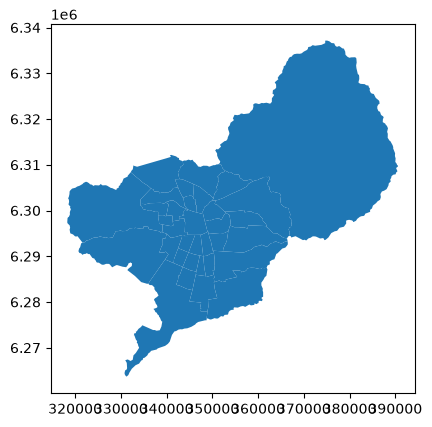

In [19]:
gdf_comuna.plot()

### Analisis exploratorio de Datos (EDA)
#### Graficos de Barra por Comuna

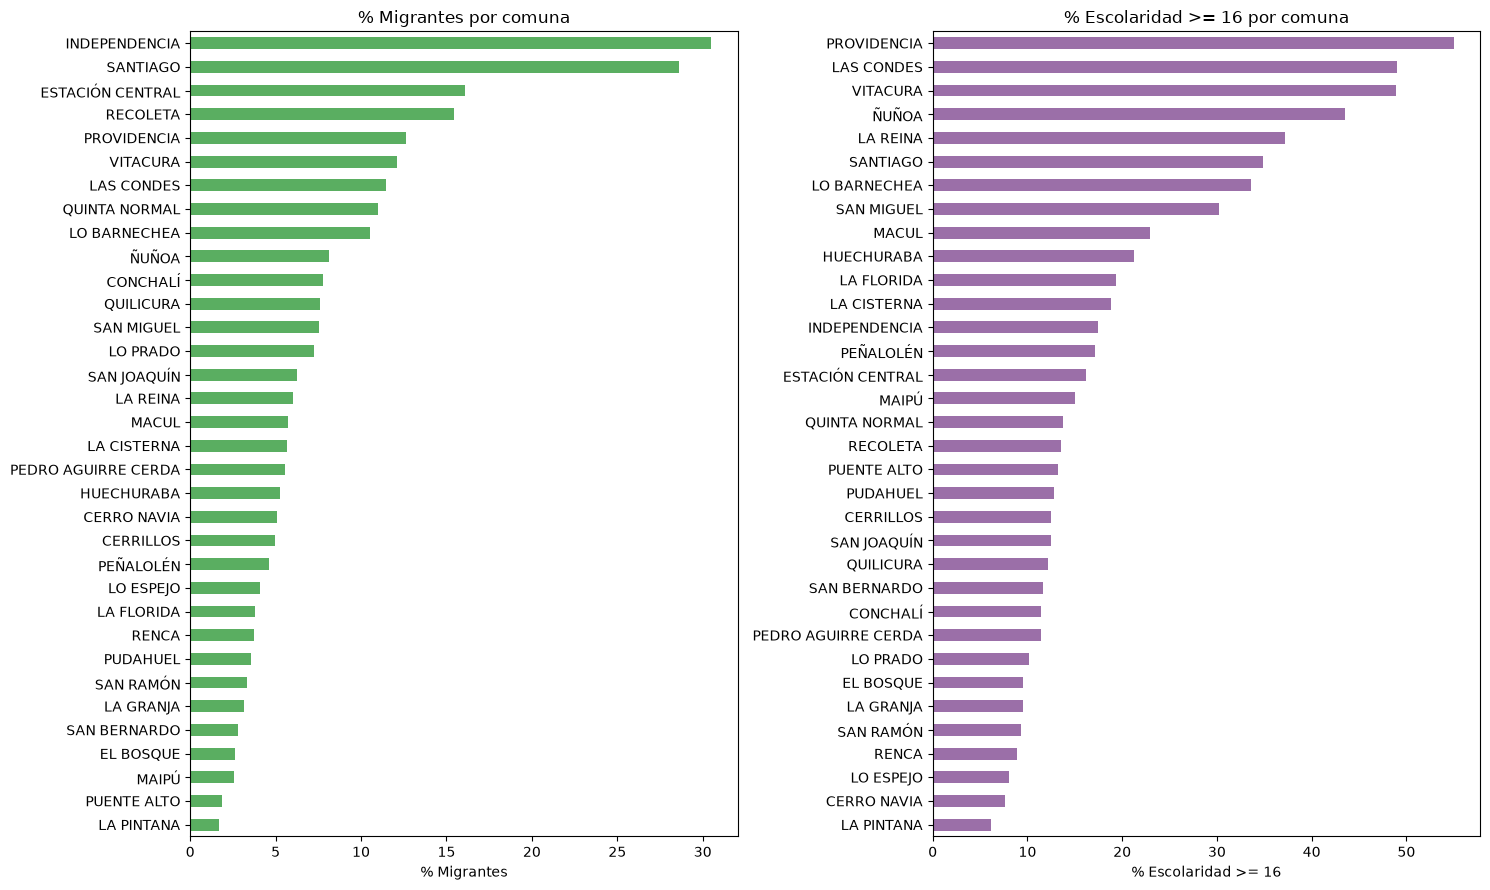

In [21]:
prom = gdf_comuna.set_index('nom_comuna')

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

prom['ptje_migrantes'].sort_values().plot.barh(ax=axes[0], color='#5aae61')
axes[0].set_title('% Migrantes por comuna')
axes[0].set_xlabel('% Migrantes')
axes[0].set_ylabel('')

prom['ptje_esc_mayor_16'].sort_values().plot.barh(ax=axes[1], color='#9b6fa8')
axes[1].set_title('% Escolaridad >= 16 por comuna')
axes[1].set_xlabel('% Escolaridad >= 16')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Mapa Comunal

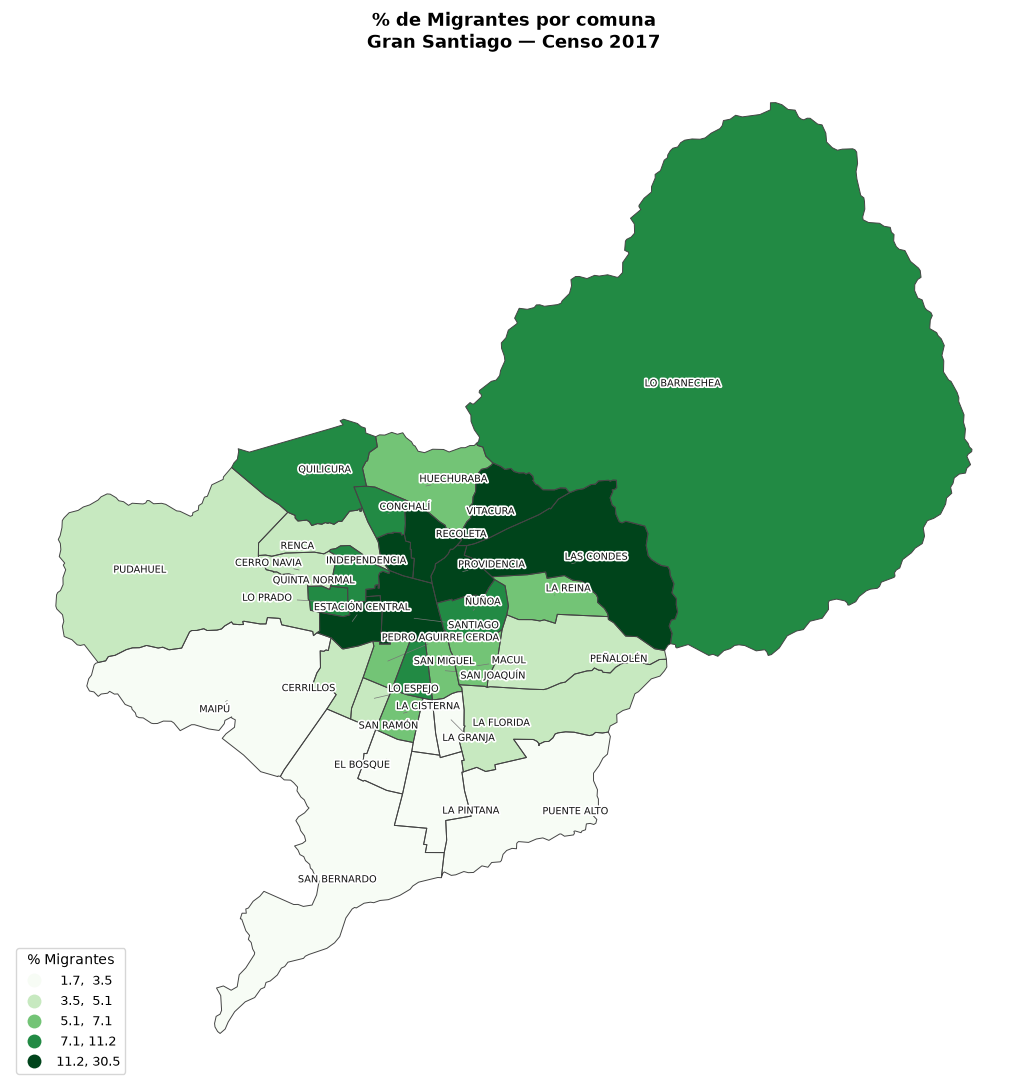

In [27]:
fig, ax = plt.subplots(figsize=(11, 11))

# Coropleta: color por cuantiles (sin borde en el relleno)
gdf_comuna.plot(column='ptje_migrantes', cmap='Greens',
                scheme='quantiles', k=5,
                legend=True,
                legend_kwds={'title': '% Migrantes', 'loc': 'lower left',
                             'fontsize': 9, 'title_fontsize': 10, 'fmt': '{:.1f}'},
                ax=ax)

# Bordes comunales nitidos encima (gris oscuro, se ven sobre cualquier color)
gdf_comuna.boundary.plot(ax=ax, color='#444444', linewidth=0.7)

# Etiqueta de cada comuna sobre un punto interior, con halo blanco
puntos = gdf_comuna.geometry.representative_point()
textos = [
    ax.text(punto.x, punto.y, nombre, ha='center', va='center',
            fontsize=7, color='#111',
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    for punto, nombre in zip(puntos, gdf_comuna['nom_comuna'])
]

# Separa automaticamente las etiquetas que se enciman y dibuja una linea guia
adjust_text(textos, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#777', lw=0.5))

ax.set_title('% de Migrantes por comuna\nGran Santiago — Censo 2017',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

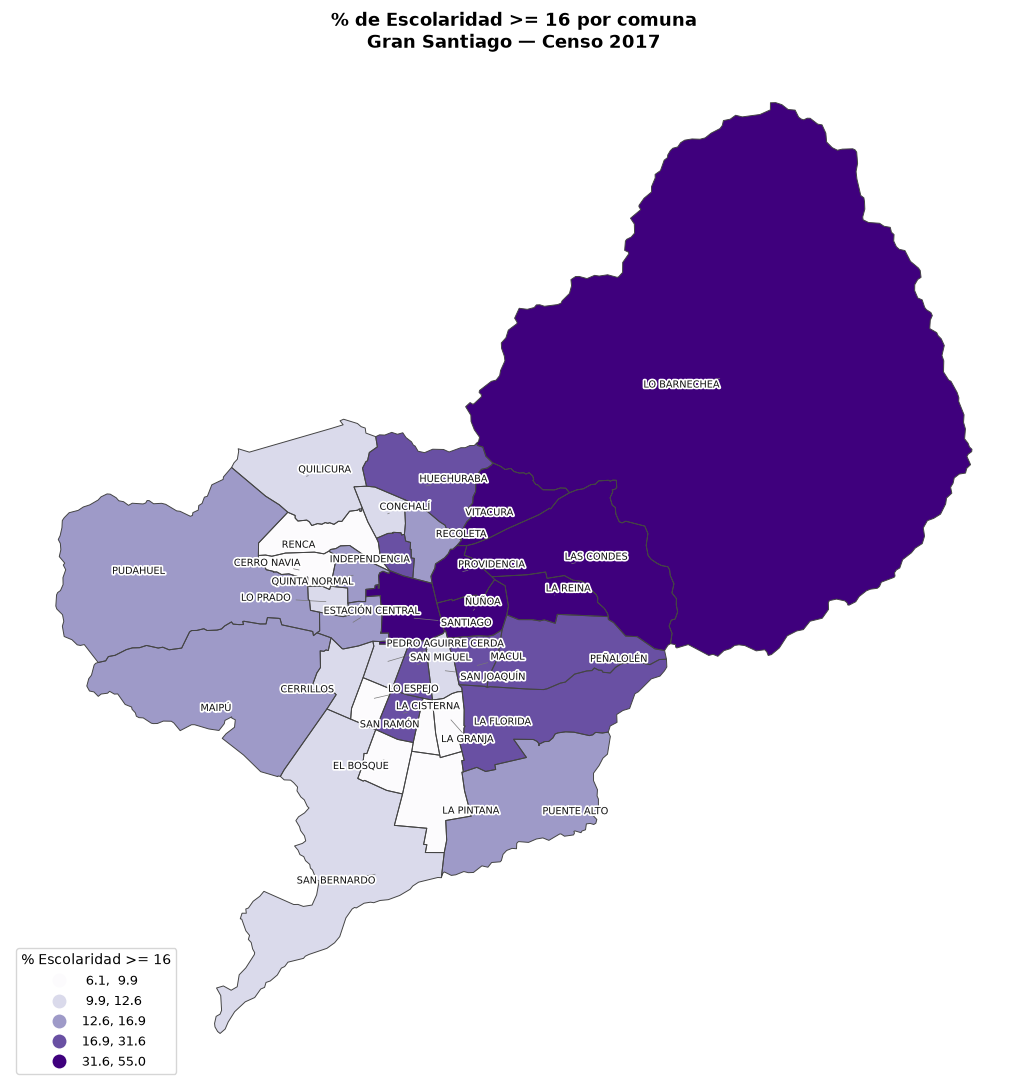

In [28]:
fig, ax = plt.subplots(figsize=(11, 11))

gdf_comuna.plot(column='ptje_esc_mayor_16', cmap='Purples',
                scheme='quantiles', k=5,
                legend=True,
                legend_kwds={'title': '% Escolaridad >= 16', 'loc': 'lower left',
                             'fontsize': 9, 'title_fontsize': 10, 'fmt': '{:.1f}'},
                ax=ax)

# Bordes comunales nitidos encima
gdf_comuna.boundary.plot(ax=ax, color='#444444', linewidth=0.7)

# Etiqueta de cada comuna sobre un punto interior, con halo blanco
puntos = gdf_comuna.geometry.representative_point()
textos = [
    ax.text(punto.x, punto.y, nombre, ha='center', va='center',
            fontsize=7, color='#111',
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    for punto, nombre in zip(puntos, gdf_comuna['nom_comuna'])
]

# Separa automaticamente las etiquetas que se enciman y dibuja una linea guia
adjust_text(textos, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#777', lw=0.5))

ax.set_title('% de Escolaridad >= 16 por comuna\nGran Santiago — Censo 2017',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()